In [ ]:
!pip install datasets transformers accelerate evaluate imbalanced-learn
!pip install arabic-reshaper python-bidi wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 9.1 MB/s eta 0:00:00


In [ ]:
#import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from datasets import Dataset
import torch

In [ ]:
#dowlnload dziriBERT
tokenizer = AutoTokenizer.from_pretrained("alger-ia/dziribert")
model = AutoModel.from_pretrained("alger-ia/dziribert")




/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/176 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#load the dataset
dataset = load_dataset("arbml/Twifil")
dataset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001-eef2e32ea1bb4a(…):   0%|          | 0.00/699k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['ID', 'Code', 'Post', 'lang', 'Created At', 'Followers Count', 'Profile Link Color', 'Geo Enabled', 'Screen Name', 'Name', 'Profile Lang', 'Polarity', 'Polarity Class', 'User Age', 'Emotion', 'Platform'],
        num_rows: 6000
    })
})

In [ ]:
twifil = dataset["train"].to_pandas()
twifil.head()


,ID,Code,Post,lang,Created At,Followers Count,Profile Link Color,Geo Enabled,Screen Name,Name,Profile Lang,Polarity,Polarity Class,User Age,Emotion,Platform
0,1,9.5283479986508e+17,@gamehacker080 @WaellAmeer @Kempa2010 @omeralb...,ar,Mon Jan 15 09:28:13 +0000 2018,215,0084B4,1,JackoTyga,Amine Jacko,fr,"3,43",Positive,26.0,nan,Twitter
1,2,9.5283475039334e+17,@arar12332095361 صل الله عليه و سلم,ar,Mon Jan 15 09:28:01 +0000 2018,1682,19CF86,1,aminoooo_amine,Amine Bourahla,fr,"7,14",Positive,26.0,nan,Twitter
2,3,9.5283463826695e+17,@SRKFC1 @iamsrk @gaurikhan 💖💖💖💖💖💖 https://t.co...,und,Mon Jan 15 09:27:35 +0000 2018,114,1DA1F2,1,FoufaKiri,Foufa kiri,fr,"3,33",Positive,nan,nan,Twitter
3,4,9.5283457943348e+17,.@realDonaldTrump YOU did this you started it!...,en,Mon Jan 15 09:27:21 +0000 2018,5367,E81C4F,1,Spartanise,Spartanise,en,"-6,29",Negative,nan,nan,Twitter
4,5,9.5283405417663e+17,"وقال: "" ... وعليهم *أَنْ يكونوا على يقظةٍ* مِن...",ar,Mon Jan 15 09:25:15 +0000 2018,135,1DA1F2,1,GhanayK,أبو العباس كريم,ar,"-2,71",Negative,nan,nan,Twitter


In [ ]:
twifil.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  6000 non-null   object
 1   Code                6000 non-null   object
 2   Post                6000 non-null   object
 3   lang                6000 non-null   object
 4   Created At          6000 non-null   object
 5   Followers Count     6000 non-null   object
 6   Profile Link Color  6000 non-null   object
 7   Geo Enabled         6000 non-null   object
 8   Screen Name         6000 non-null   object
 9   Name                6000 non-null   object
 10  Profile Lang        6000 non-null   object
 11  Polarity            6000 non-null   object
 12  Polarity Class      6000 non-null   object
 13  User Age            6000 non-null   object
 14  Emotion             6000 non-null   object
 15  Platform            6000 non-null   object
dtypes: object(16)
memory usa

In [ ]:
#ETAPE 1 : Analyse Exploratoire du Corpus TWIFL

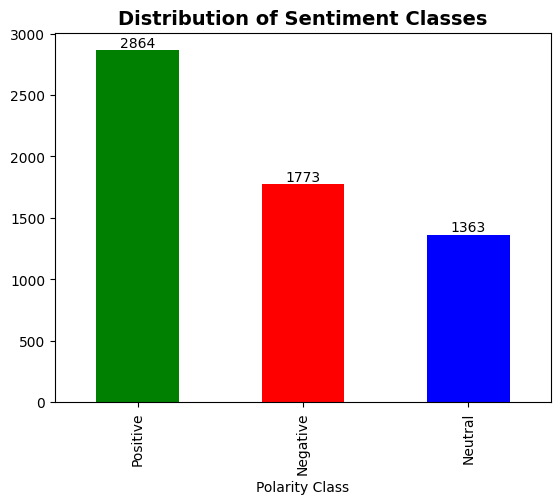

In [ ]:
class_counts = twifil["Polarity Class"].value_counts().plot(
    kind="bar"
)

# Define the colors
bar_colors = ['green', 'red', 'blue']

# Set the colors for each bar
for i, bar in enumerate(class_counts.patches):
    bar.set_facecolor(bar_colors[i % len(bar_colors)])

plt.title("Distribution of Sentiment Classes" , fontsize=14, fontweight='bold')
for container in class_counts.containers:
    class_counts.bar_label(container)

plt.show()

In [ ]:
# le ratio de déséquilibre
class_counts = twifil["Polarity Class"].value_counts()
ratio = class_counts.max() / class_counts.min()
ratio

2.1012472487160676

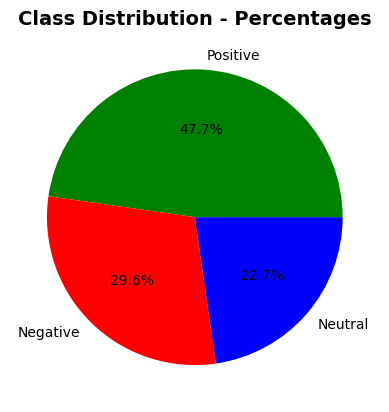

In [ ]:
#in percentage
# Pie Chart
twifil['Polarity Class'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['green','red','blue'])

plt.title("Class Distribution - Percentages",fontsize=14, fontweight="bold")
plt.ylabel('')
plt.show()

In [ ]:
twifil.to_csv("twifil_dataset.csv", index=False)


In [ ]:
!pip freeze > requirements.txt


In [ ]:
#1-2 :analyse linguistique de tweet

In [ ]:
#Vérifier les valeurs de la variable cible
twifil["Polarity Class"].unique()


array(['Positive', 'Negative', 'Neutral'], dtype=object)

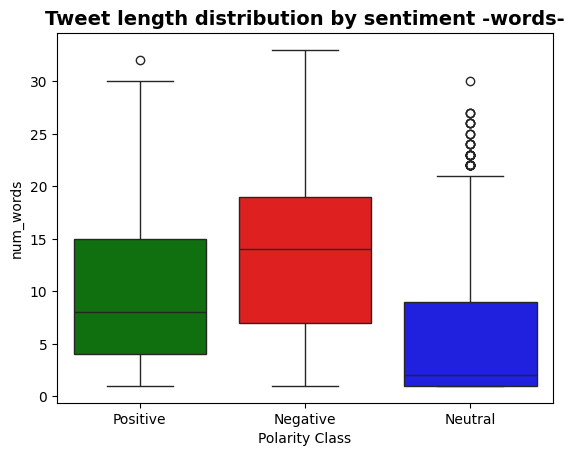

In [ ]:
#Distribution de la longueur des tweets en mots PAR CLASS
twifil["num_words"] = twifil["Post"].apply(lambda x: len(x.split()))
#visualisation by boxplot
sns.boxplot(data=twifil, x="Polarity Class", y="num_words", hue="Polarity Class", palette=['green','red','blue'], legend=False)
plt.title("Tweet length distribution by sentiment -words-", fontsize=14, fontweight='bold')
plt.show()

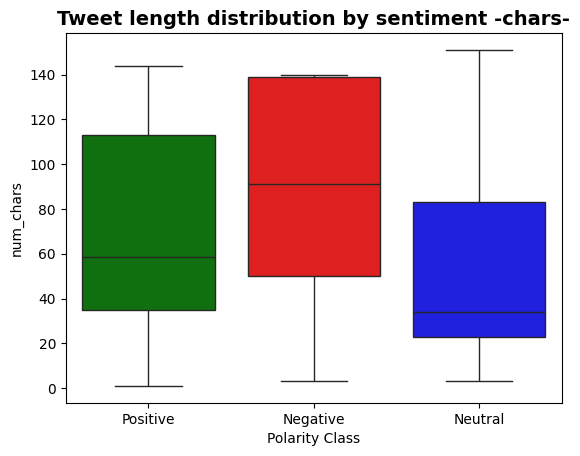

In [ ]:
#Distribution de la longueur des tweets en CARACTERE par class
twifil["num_chars"] = twifil["Post"].apply(len)
#visualisation by boxplot
sns.boxplot(data=twifil, x="Polarity Class", y="num_chars", hue="Polarity Class", palette=['green','red','blue'], legend=False)
plt.title("Tweet length distribution by sentiment -chars-" , fontsize=14, fontweight='bold')
plt.show()


In [ ]:

def detect_language(text):
    text = str(text).lower()

    arabic = bool(re.search(r'[\u0600-\u06FF]', text))
    latin = bool(re.search(r'[a-zA-Z]', text))

    arabizi = bool(re.search(r'[a-z]*[3579286][a-z]+', text))

    if arabic and latin:
        return "Code-switch"
    elif arabic:
        return "Arabic"
    elif arabizi and latin:
        return "Arabizi"
    elif latin:
        return "French/Latin"
    else:
        return "Other"
twifil["detected_lang"] = twifil["Post"].apply(detect_language)
lang_stats = twifil["detected_lang"].value_counts()

lang_table = pd.DataFrame({
    "Count": lang_stats,
    "Percentage": (lang_stats / len(twifil)) * 100
})

lang_table


,Count,Percentage
detected_lang,,
Code-switch,2300,38.333333
French/Latin,1915,31.916667
Arabizi,1512,25.200000
Arabic,257,4.283333
Other,16,0.266667


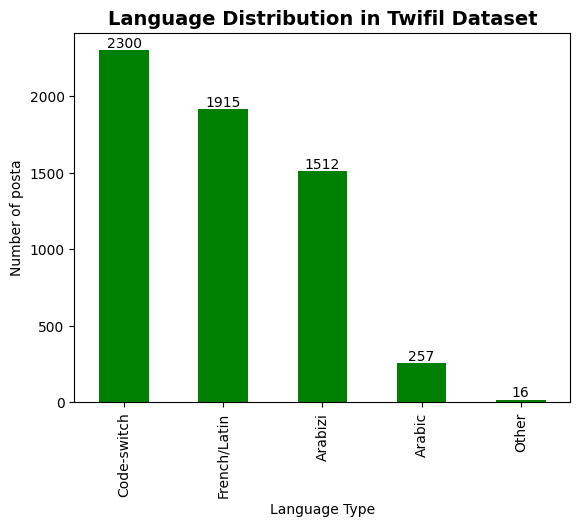

In [ ]:
#visualisation by bars
ax=twifil["detected_lang"].value_counts().plot(kind="bar",color="green")

plt.title("Language Distribution in Twifil Dataset",fontsize=14, fontweight='bold')
plt.ylabel("Number of posta")
plt.xlabel("Language Type")
for container in ax.containers:
    ax.bar_label(container)

plt.show()


In [ ]:
# langue by class tab
lang_by_sentiment = pd.crosstab(
    twifil["Polarity Class"],
    twifil["detected_lang"],
    margins=True
)

lang_by_sentiment


detected_lang,Arabic,Arabizi,Code-switch,French/Latin,Other,All
Polarity Class,,,,,,
Negative,113,312,844,501,3,1773
Neutral,11,660,219,468,5,1363
Positive,133,540,1237,946,8,2864
All,257,1512,2300,1915,16,6000


In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 15.3 MB/s eta 0:00:00


In [ ]:
#Proportion de tweets contenant des emojis
import emoji
twifil["has_emoji"] = twifil["Post"].apply(lambda x: any(char in emoji.EMOJI_DATA for char in str(x)))
emoji_stats = twifil.groupby("Polarity Class")["has_emoji"].agg([
    ("total by class", "sum"),
    ("percentage", lambda x: (x.sum() / len(x)) * 100)
])

total_row = pd.DataFrame({
    "total by class": [emoji_stats["total by class"].sum()],
    "percentage": [100.0]
}, index=["Total"])
emoji_stats = pd.concat([emoji_stats, total_row])
emoji_stats

,total by class,percentage
Negative,332,18.725324
Neutral,79,5.796038
Positive,863,30.132682
Total,1274,100.000000


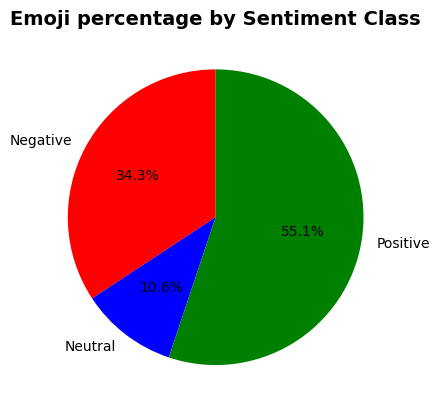

In [ ]:
#visualisation by pie char
plot_data = emoji_stats.drop("Total")

plot_data["percentage"].plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['red','blue','green']
)

plt.title("Emoji percentage by Sentiment Class", fontsize=14, fontweight="bold")
plt.ylabel('')
plt.show()


In [ ]:
#Proportion de tweets avec code-switching
def detect_code_switch(text):
    text = str(text) if pd.notna(text) else ""
    arabic = bool(re.search(r'[\u0600-\u06FF]', text))
    latin = bool(re.search(r'[a-zA-Z]', text))
    return arabic and latin
twifil["code_switch"] = twifil["Post"].apply(detect_code_switch)
twifil["code_switch"].value_counts()

# Get percentages
code_switch_pct = (twifil["code_switch"].sum() / len(twifil)) * 100
print(f"\nPercentage with code-switching: {code_switch_pct:.2f}%")

# Check by sentiment class
print("\nCode-switching by sentiment:")
code_switching = twifil.groupby("Polarity Class")["code_switch"].value_counts().unstack(fill_value=0)

#row total
code_switching["Total"] = code_switching.sum(axis=1)

# column total
total_row = pd.DataFrame(code_switching.sum()).T
total_row.index = ["Total"]
code_switching = pd.concat([code_switching, total_row])

code_switching



Percentage with code-switching: 38.33%

Code-switching by sentiment:


code_switch,False,True,Total
Negative,929,844,1773
Neutral,1144,219,1363
Positive,1627,1237,2864
Total,3700,2300,6000


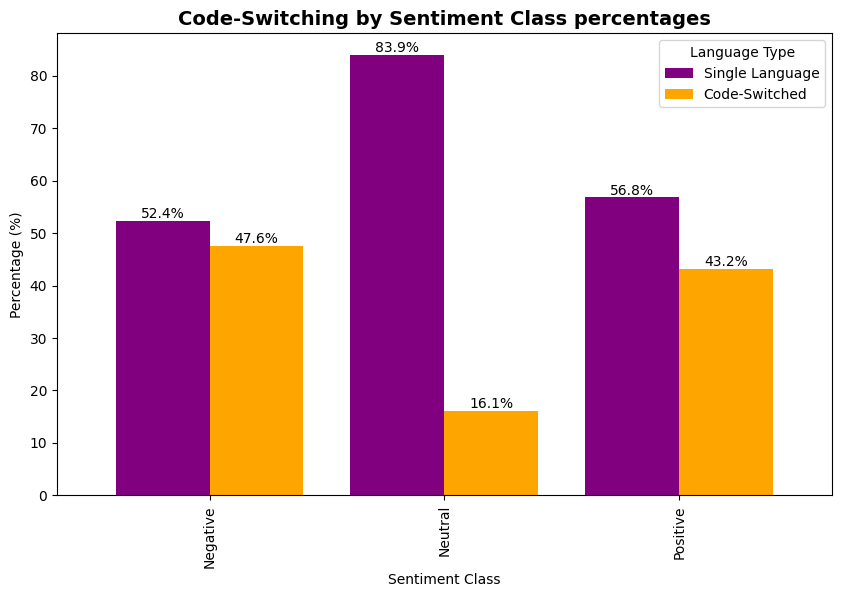

In [ ]:
# Create cross-tabulation
cross_tab = pd.crosstab(twifil["Polarity Class"], twifil["code_switch"],
                        normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
cross_tab.plot(kind='bar', ax=ax, color=['purple', 'orange'], width=0.8)

ax.set_title('Code-Switching by Sentiment Class percentages', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Percentage (%)')
ax.legend(['Single Language', 'Code-Switched'], title='Language Type')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

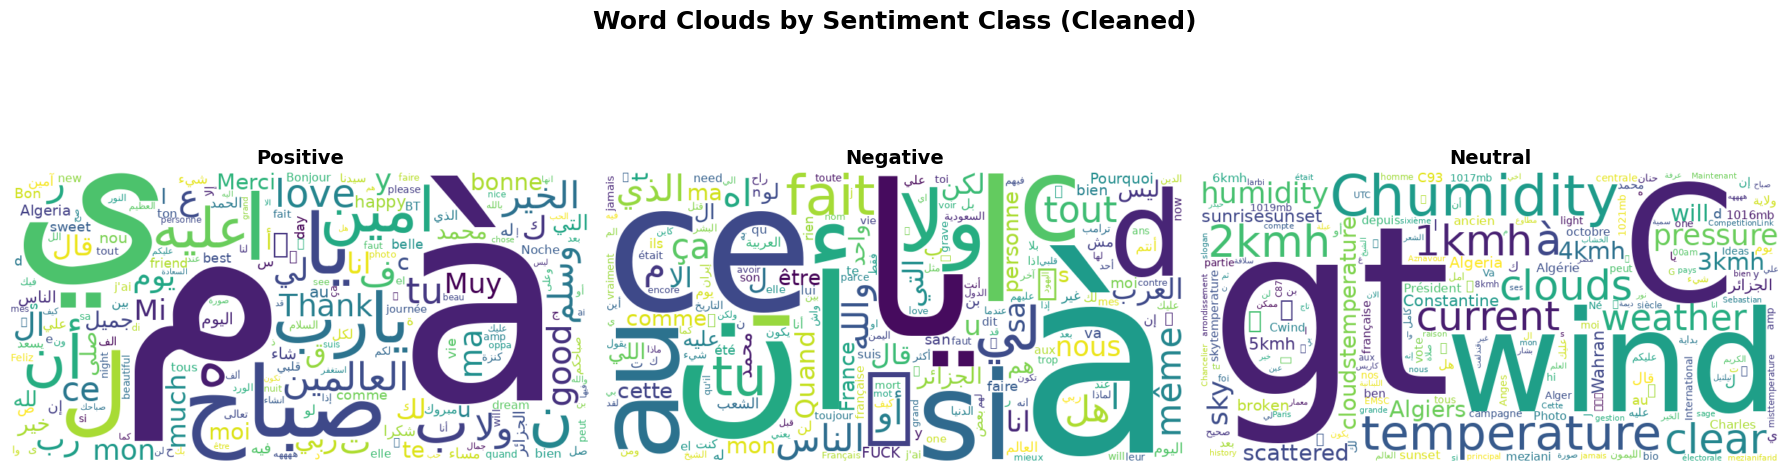

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import re

# ============================================================
# 1️⃣ Stopwords متعددة اللغات (IMPORTANT)
# ============================================================

# English stopwords (built-in)
stopwords = set(STOPWORDS)

# French stopwords
french_stopwords = {
    "le","la","les","de","des","du","un","une","et","ou","mais","vous","pour","à"
    "donc","car","ni","que","qui","quoi","est","sont","dans","a","il","je","se","si"
    "pour","avec","sur","pas","plus","moins","très","tres","ne","en","par","c'est",
    }

# Arabic stopwords (darija + classique)
arabic_stopwords = {
    "في","من","على","الى","إلى","عن","مع","هذا","هذه","ذلك","اللهم","صباح"
    "انا","انت","هو","هي","نحن","كان","ما","لا","نعم","كي","الله","حتى",
    "راهو","راهي","كانو","كون","باش","علاش","كيفاش","لم","ان","كل","و"
}

# Darija / Arabizi stopwords
darija_stopwords = {
    "ana","nta","nti","hna","kima","bch","rani","rah","rahom",
    "3la","fi","men","ela","wach","wesh","oui","non","saha",
    "kho","ya","lol","mdr","svp","stp","ok","gtc"
}

# دمج الكل
stopwords.update(french_stopwords)
stopwords.update(arabic_stopwords)
stopwords.update(darija_stopwords)

# ============================================================
# 2️⃣ WordCloud
# ============================================================

sentiments = twifil['Polarity Class'].unique()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, sentiment in enumerate(sentiments):
    sentiment_texts = twifil[twifil['Polarity Class'] == sentiment]['Post']

    all_text = ' '.join(sentiment_texts.astype(str))

    # تنظيف إضافي
    all_text = re.sub(r'http\S+|@\w+|#\w+', '', all_text)  # remove url, mention, hashtag
    all_text = re.sub(r'[\x00-\x1F\x7F\u200B-\u200F\uFEFF]', '', all_text)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=200,
        stopwords=stopwords,   # 🔥 هنا الإضافة المهمة
        font_path=font_path,
        colormap='viridis',
        collocations=False,
        random_state=42
    ).generate(all_text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(sentiment, fontsize=14, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment Class (Cleaned)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# BERT embeddings AVANT prétraitement/rééquilibrage
tokenizer = AutoTokenizer.from_pretrained("alger-ia/dziribert")
model = AutoModel.from_pretrained("alger-ia/dziribert")

texts = twifil["Post"][:600]
labels = twifil["Polarity Class"][:600]

embeddings = []

for text in texts:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    cls = outputs.last_hidden_state[:,0,:].squeeze().numpy()
    embeddings.append(cls)

embeddings = np.array(embeddings)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X = pca.fit_transform(embeddings)
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(X, labels)

import matplotlib.pyplot as plt

colors = {
    "Positive": "green",
    "Negative": "red",
    "Neutral": "blue"
}

plt.figure(figsize=(8,6))

for sentiment in colors:
    idx = labels == sentiment
    plt.scatter(
        X[idx,0],
        X[idx,1],
        c=colors[sentiment],
        label=sentiment,
        alpha=0.6
    )

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.title("2D Sentiment Classification Boundary")
plt.legend()
plt.show()


In [ ]:
  #tableau statistique

stats = twifil.groupby("Polarity Class").agg(
    nb_examples=("Post", "count"),
    avg_words=("Post", lambda x: x.str.split().apply(len).mean()),
    avg_characters=("Post", lambda x: x.str.len().mean())
)

stats["percentage"] = (stats["nb_examples"] / len(twifil)) * 100
total_row = pd.DataFrame({
    "nb_examples": [stats["nb_examples"].sum()],
    "avg_words": [stats["avg_words"].mean()],
    "avg_characters": [stats["avg_characters"].mean()],
    "percentage": [100.0]
}, index=["Total"])
stats = pd.concat([stats, total_row])
stats
